# Project 1 — Issue Report Classification
## Notebook 04: Neural networks

**Track C deliverable.**

Two architectures from the course:

- **Feed-forward network** over TF-IDF features — directly comparable with
  Track B, since it consumes exactly the same representation.
- **1-D convolutional network** over learned word embeddings — filters of
  several widths act as learned n-gram detectors, and global max-pooling keeps
  the strongest activation regardless of where in the document it occurred.

Both track training and validation loss at every epoch, which the course
requires, and both use early stopping.

In [1]:
import json

import pandas as pd

from ai4se.classical import TUNED_PREPROCESSING
from ai4se.evaluation import leaderboard_from_disk
from ai4se.loader import PROJECT_ROOT, load_split
from ai4se.neural import CNNTextClassifier, FeedForwardClassifier, plot_learning_curves
from ai4se.preprocessing import make_cleaner

%matplotlib inline
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

pd.set_option("display.width", 140)
TABLES = PROJECT_ROOT / "results" / "tables"
FIGURES = PROJECT_ROOT / "results" / "figures"

train = load_split("train", kind="memory")
test = load_split("test", kind="memory")
train.apply(make_cleaner(**TUNED_PREPROCESSING))
test.apply(make_cleaner(**TUNED_PREPROCESSING))

react_train = train.by_repo("facebook/react")
X = [i.text for i in react_train]
y = [i.label for i in react_train]
print(f"one project: {len(X)} training issues")

one project: 300 training issues


---
## 1. Validation curves

The course prescribes reporting and comparing training and validation loss at
each epoch, and treats the validation curve as the standard overfitting
diagnostic. Roughly 20% of the training data is held out for this.

Watch the gap open between the two lines: that is overfitting appearing. With
only 300 training issues per project it appears quickly.

epochs run     : 23
best epoch     : 15
stopped early  : True


,train_loss,val_loss,val_accuracy
epoch,,,
1,1.0986,1.0935,0.3333
2,1.0802,1.0766,0.5833
3,1.0362,1.0469,0.6333
4,0.9580,0.9955,0.6167
5,0.8135,0.9178,0.6167
6,0.6225,0.8186,0.6333
7,0.3938,0.7226,0.6833
8,0.2206,0.6527,0.6833
9,0.1153,0.6126,0.6833


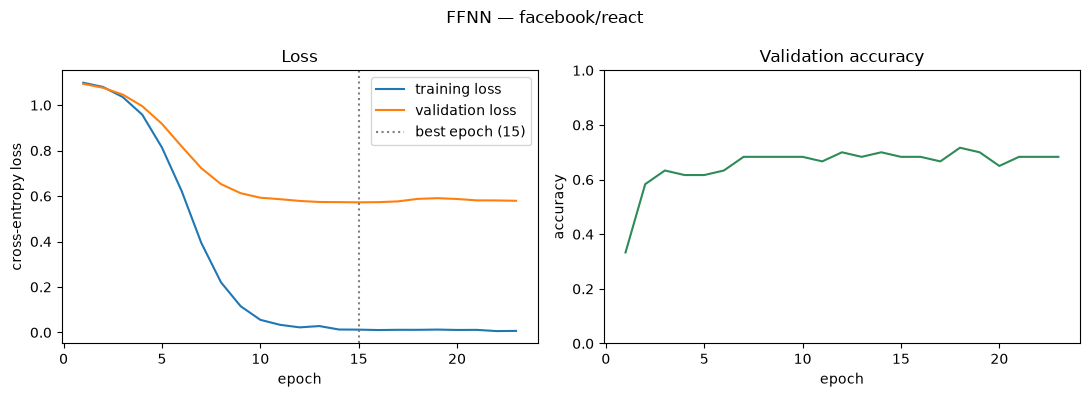

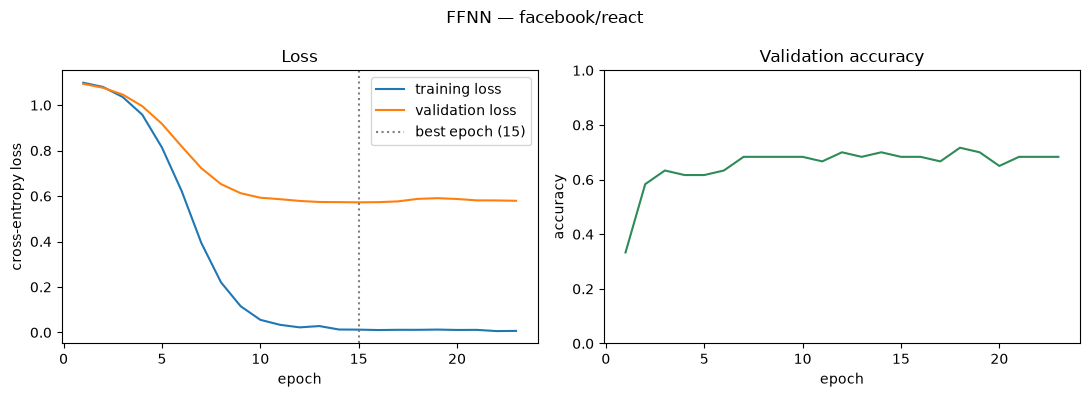

In [2]:
model = FeedForwardClassifier(epochs=60, patience=8, verbose=False).fit(X, y)
history = model.history_

print(f"epochs run     : {len(history.train_loss)}")
print(f"best epoch     : {history.best_epoch}")
print(f"stopped early  : {history.stopped_early}")
display(history.to_frame().head(12).round(4))

plot_learning_curves(history, title="FFNN — facebook/react")

Training loss keeps falling while validation loss bottoms out and then rises —
the textbook picture of a model that has started memorising. Early stopping
halts training once validation loss has not improved for eight epochs, and the
weights from the best epoch are restored rather than the last ones.

**This is the section to point at in the oral** when asked how overfitting was
detected and handled. The course lists early stopping, simpler architectures and
cross-validation as the remedies; the first is implemented here, the second is
forced by the dataset size, and the third is the harness from Track D.

CNN: 38 epochs, best 30, early stop True


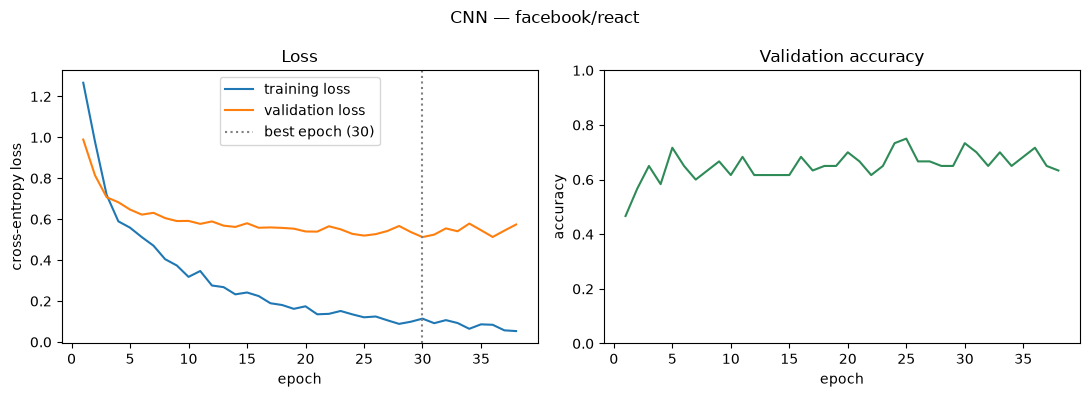

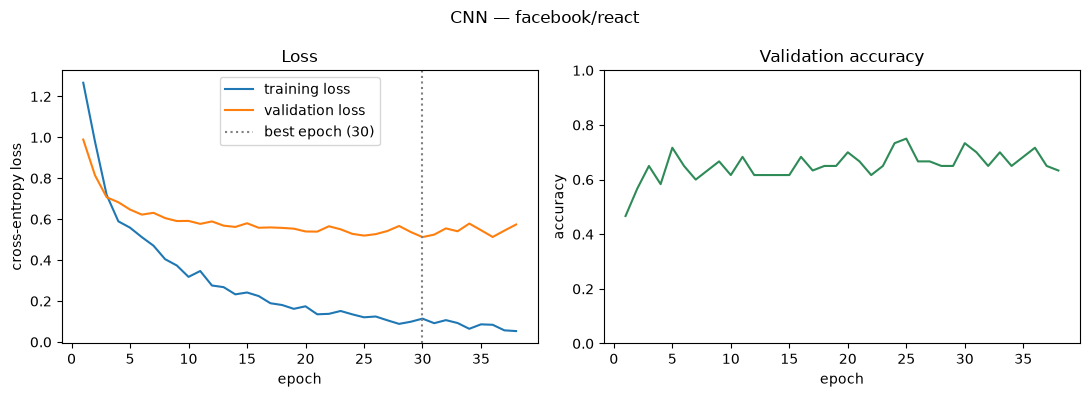

In [3]:
cnn = CNNTextClassifier(epochs=60, patience=8).fit(X, y)
print(f"CNN: {len(cnn.history_.train_loss)} epochs, best {cnn.history_.best_epoch}, "
      f"early stop {cnn.history_.stopped_early}")
plot_learning_curves(cnn.history_, title="CNN — facebook/react")

The CNN overfits more slowly: it has fewer effective parameters acting on each
input position, and the embedding layer is learned from scratch, so it takes
longer to reach the point of memorising.

---
## 2. Results on the competition protocol

In [4]:
board = leaderboard_from_disk(TABLES)
display(board[board.index.str.contains("FFNN|CNN|SetFit|tuned")])

,react,tensorflow,vscode,bitcoin,opencv,overall,AUC,vs SetFit
model,,,,,,,,
SetFit (NLBSE'24 baseline),0.8718,0.8644,0.8262,0.7555,0.8173,0.8270,NaN,0.0000
Ensemble (SetFit + TF-IDF + MPNet),0.8505,0.8520,0.7957,0.7691,0.8168,0.8168,0.9319,-0.0102
SetFit (MPNet),0.8438,0.8710,0.8104,0.7488,0.7771,0.8102,0.9190,-0.0168
Ensemble (SetFit + TF-IDF),0.8396,0.8521,0.7922,0.7459,0.7966,0.8053,0.9244,-0.0217
SetFit (reproduction),0.8322,0.8414,0.7816,0.7464,0.7896,0.7982,0.9181,-0.0288
Ensemble (TF-IDF + MPNet + CNN),0.8296,0.8395,0.7494,0.7694,0.7665,0.7909,0.9245,-0.0361
"SetFit (MiniLM, matched settings)",0.7934,0.8618,0.7624,0.7170,0.7735,0.7816,0.9144,-0.0454
TF-IDF + Logistic Regression (tuned),0.8334,0.8155,0.7234,0.6793,0.7496,0.7603,0.9018,-0.0667
TF-IDF + Linear SVM (tuned),0.8002,0.8021,0.7332,0.6854,0.7448,0.7531,NaN,-0.0739


In [5]:
for name in ["ffnn_tf_idf", "cnn_embeddings"]:
    history = json.loads((TABLES / f"history_{name}.json").read_text())
    print(f"{name:<16} epochs={history['epochs_run']:>3}  "
          f"best={history['best_epoch']:>3}  early_stop={history['stopped_early']}")

ffnn_tf_idf      epochs= 23  best= 15  early_stop=True
cnn_embeddings   epochs= 38  best= 30  early_stop=True


The CNN reaches **0.7578**, marginally below the best classical pipeline
(0.7603) and comfortably above the FFNN (0.7467).

**The interesting result is that neither neural model beats TF-IDF.** With 300
training issues per project there is not enough data to learn a better
representation than TF-IDF already provides, and the CNN has to learn its
embeddings from scratch. The competition's per-project protocol is what creates
this constraint: a global model would have 1,500 issues, but Track D showed
per-project training wins anyway.

This is the argument for Track D2: a *pretrained* representation is the only way
to bring outside knowledge into a 300-example problem.